## 서브그래프 (Sub-graph)
- 서브그래프는 LangGraph에서 복잡한 AI 시스템을 관리 가능한 단위로 모듈화하는 핵심 개념
- **더 큰 그래프 내에서 독립적으로 실행되는 작은 그래프로, 자체적인 상태와 노드, 엣지를 가질 수 있음**

<br>

### 서브그래프의 활용 목적
- **멀티 에이전트 시스템**: 각 에이전트를 독립된 서브그래프로 구현
- **재사용**: 동일한 노드 집합을 여러 그래프에서 재사용
- **분산 개발**: 서브그래프 인터페이스(입출력 스키마)만 준수하면 독립적으로 개발 가능

<br>

### 서브그래프 추가 방법
- 서브그래프를 부모 그래프에 추가하는 방법

<img src='./img/1-11-1.png' width=600>

<br>

<table>
<thead>
<tr>
<th>방법</th>
<th>상태 공유</th>
<th>사용 사례</th>
</tr>
</thead>
<tbody>
<tr>
<td><code>add_node</code>로 직접 추가</td>
<td>공유 키 자동 매핑</td>
<td>동일하거나 유사한 스키마</td>
</tr>
<tr>
<td>노드 함수 내에서 <code>invoke</code></td>
<td>완전히 다른 스키마 가능</td>
<td>프라이빗 메시지 히스토리 등</td>
</tr>
</tbody>
</table>

<br>

#### `add_node`로 직접 추가 (스키마 공유 상태)
- **부모 그래프와 서브그래프가 상태 키를 공유하는 경우, 컴파일된 서브그래프를 `add_node`에 직접 전달**
- **서브그래프의 프라이빗 키(bar)는 부모 그래프에서 보이지 않으며, 공유 키(foo)만 부모 그래프로 전달.**
  
  이를 통해 서브그래프 내부 상태를 캡슐화하고 인터페이스를 단순하게 유지할 수 있음

<img src='./img/1-11-2.png' width=600>

<br>


In [19]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from visualize_graph import visualize_graph

- 서브그래프 정의

In [20]:
class SubgraphState(TypedDict):
    foo: str  # 부모 그래프와 공유하는 키
    bar: str  # 서브그래프에서만 사용하는 프라이빗 키

In [21]:
def subgraph_node_1(state: SubgraphState):
    return {"bar": "bar"}

def subgraph_node_2(state: SubgraphState):
    # 프라이빗 키(bar)를 사용하여 공유 키(foo)를 업데이트
    return {"foo": state["foo"] + state["bar"]}

In [22]:
subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()

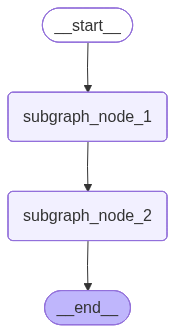

In [28]:
visualize_graph(subgraph)

- 부모 그래프 정의
  - 컴파일된 서브그래프를 직접 추가

In [23]:
class ParentState(TypedDict):
    foo: str

In [24]:
def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}

In [25]:
builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", subgraph)  # 컴파일된 서브그래프를 직접 추가
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph = builder.compile()

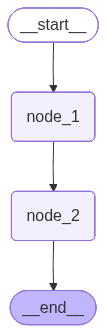

In [26]:
visualize_graph(graph)

In [27]:
for chunk in graph.stream({"foo": "foo"}):
    print(chunk)

{'node_1': {'foo': 'hi! foo'}}
{'node_2': {'foo': 'hi! foobar'}}


<br>

#### 노드 함수 내에서 `invoke` (스키마 독립)
- **부모 그래프와 서브그래프가 완전히 다른 스키마를 사용하는 경우, 노드 함수 내에서 서브그래프를 호출하고 상태를 변환**
- **이 방법은 각 에이전트가 자체 메시지 히스토리를 유지해야 하는 멀티 에이전트 시스템에서 유용**

<br>



In [29]:
from typing_extensions import TypedDict, Annotated
from langchain.chat_models import init_chat_model
from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages

In [30]:
model = init_chat_model("openai:gpt-4o-mini")

- 서브그래프 상태 - 다른 스키마

In [33]:
class SubgraphMessagesState(TypedDict):
    subgraph_messages: Annotated[list[AnyMessage], add_messages]

In [34]:
def call_model(state: SubgraphMessagesState):
    response = model.invoke(state["subgraph_messages"])
    return {"subgraph_messages": response}

In [39]:
subgraph_builder = StateGraph(SubgraphMessagesState)
subgraph_builder.add_node("call_model_from_subgraph", call_model)
subgraph_builder.add_edge(START, "call_model_from_subgraph")
subgraph = subgraph_builder.compile()

-  부모 그래프 - 상태 변환 함수 정의


In [36]:
def call_subgraph(state: MessagesState):
    # 부모 상태 → 서브그래프 상태로 변환
    response = subgraph.invoke({"subgraph_messages": state["messages"]})
    # 서브그래프 상태 → 부모 상태로 변환하여 반환
    return {"messages": response["subgraph_messages"]}

In [37]:
builder = StateGraph(MessagesState)
builder.add_node("subgraph_node", call_subgraph)
builder.add_edge(START, "subgraph_node")
graph = builder.compile()

In [38]:
graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='327636fe-fdb5-4fe9-ba5d-e2f9ce2eb151'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 9, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_dc5460657f', 'id': 'chatcmpl-DlmFwaY6bsd0dkxghB6WXOkwkUxvS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e80ea-0c59-7670-8a29-20a8b34d4345-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 9, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': 

<br>

#### 서브그래프 스트리밍
- 서브그래프의 출력을 스트리밍하려면 `subgraphs=True` 옵션을 사용

<br>

```python
for namespace, chunk in graph.stream(
    {"foo": "foo"},
    stream_mode="updates",
    subgraphs=True,  # 서브그래프 출력 포함
):
    if namespace:
        print(f"서브그래프: {chunk}")
    else:
        print(f"메인 그래프: {chunk}")
```


<br>

#### 체크포인터 전파
- **부모 그래프에만 체크포인터를 설정하면 LangGraph가 자동으로 서브그래프에 전파**

<br>

```python
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# 부모 그래프 컴파일 시에만 체크포인터 설정
graph = builder.compile(checkpointer=memory)

# 서브그래프에도 자동으로 체크포인터가 전파됨
```

<br>

- **특정 서브그래프가 자체 메모리를 유지해야 하는 경우(예: 에이전트별 독립 대화 히스토리), 해당 서브그래프를 컴파일할 때 `checkpointer=True`를 설정**

```python
# 서브그래프가 독립적인 메모리를 유지
subgraph = subgraph_builder.compile(checkpointer=True)

# 부모 그래프에서 사용
builder.add_node("agent", subgraph)
graph = builder.compile(checkpointer=True)
```

<br>

#### 서브그래프 상태 조회
- 영속성이 활성화된 경우, 서브그래프의 상태를 조회할 수 있음

<br>

```python
# 기본 상태 조회
state = graph.get_state(config)

# 서브그래프 상태 포함 조회
state = graph.get_state(config, subgraphs=True)
```

<br>

- 서브그래프가 `interrupt` 상태일 때만 해당 서브그래프의 상태를 조회할 수 있음
- **정적 발견(Static Discovery) 조건**
  - `get_state(config, subgraphs=True)`가 동작하려면 LangGraph가 서브그래프를 정적으로 발견할 수 있어야 함 
  - 다음 두 가지 방법으로 추가된 서브그래프만 상태 조회가 가능
    - `add_node("name", compiled_subgraph)` : 노드로 직접 추가
    - 노드 함수 내에서 `subgraph.invoke()` : 함수 내 호출
  - 주의: 도구(tool) 함수 내부에서 서브그래프를 호출하는 경우에는 LangGraph가 서브그래프를 자동으로 발견할 수 없어 상태 조회가 불가

<br>

#### 서브그래프 설계
- **단일 책임 원칙** : 각 서브그래프는 명확한 하나의 책임을 가져야 하며, 과도한 기능 통합은 지양
- **느슨한 결합** : 서브그래프 간의 의존성을 최소화하고, 명확한 인터페이스(입출력 스키마)를 정의
- **상태 관리**
  - 순환 참조를 지양
  - 불필요한 상태 공유를 최소화
  - 서브그래프의 깊이를 적절히 제한
- **서브그래프 디버깅 팁**
  - `subgraphs=True` 스트리밍: 각 서브그래프의 실행 과정을 자세히 확인 가능

- **상태 조회**: `get_state(config, subgraphs=True)`로 서브그래프 상태 검사
- **로깅**: 각 서브그래프 노드에 로깅을 추가하여 실행 흐름 추적

<br>

<hr>

<br>

### 서브그래프 구현

<br>

#### 상태 정의
- LangGraph에서 권장하는 `add_messages` 리듀서를 사용하면 메시지 목록을 자동으로 관리
  - **`add_messages`는 단순한 리스트 추가(`operator.add`)와 달리, 메시지 ID 기반의 중복 제거와 메시지 업데이트를 지원**


In [41]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [42]:
class SubGraphState(TypedDict):
    """서브그래프의 상태를 정의하는 클래스"""
    messages: Annotated[list, add_messages]  # 메시지 히스토리
    context: str  # 컨텍스트 정보

<br>

#### 노드 함수 구현

In [43]:
def process_node(state: SubGraphState):
    """입력 메시지를 처리하는 노드"""
    current_message = state["messages"][-1]
    processed_result = f"Processed: {current_message.content}"
    return {"context": processed_result}

def respond_node(state: SubGraphState):
    """응답을 생성하는 노드"""
    context = state["context"]
    response = AIMessage(content=f"Response based on: {context}")
    return {"messages": [response]}

<br>

#### 그래프 구성

In [45]:
subgraph = StateGraph(SubGraphState)

subgraph.add_node("process", process_node)
subgraph.add_node("respond", respond_node)

subgraph.add_edge(START, "process")
subgraph.add_edge("process", "respond")
subgraph.add_edge("respond", END)

compiled_subgraph = subgraph.compile()

<img src='./img/1-11-3.png' width=600>

<br>

#### 서브그래프 실행


In [46]:
initial_state = {
    "messages": [HumanMessage(content="Hello!")],
    "context": ""
}

result = compiled_subgraph.invoke(initial_state)

for message in result["messages"]:
    print(f"Message: {message.content}")


Message: Hello!
Message: Response based on: Processed: Hello!


<br>

<hr>

<br>

### 메인 그래프에 통합

<br>

#### 메인 그래프 상태 정의
- **서브그래프와 스키마 일부 공유 : `messages`, `context`**

In [49]:
from typing import Optional, List, Literal

In [50]:
class MainState(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]
    context: str
    subgraph_result: Optional[str]
    processing_status: str

<br>

#### 메인 그래프 노드 함수 구현

In [51]:
def preprocessing(state: MainState) -> dict:
    """데이터 전처리를 수행하는 노드"""
    return {
        "context": f"Context from: {state['messages'][-1].content}",
        "processing_status": "preprocessing_complete"
    }

def postprocessing(state: MainState) -> dict:
    """서브그래프 실행 결과를 후처리하는 노드"""
    context = state.get("context", "")
    return {
        "subgraph_result": f"Final result based on context: {context}",
        "processing_status": "complete"
    }

<br>

#### 라우팅 로직
- 워크플로우의 흐름을 제어하는 라우팅 함수

In [52]:
def route_after_subgraph(state: MainState) -> Literal["postprocessing", "reprocess"]:
    """서브그래프 처리 결과에 따라 다음 단계 결정"""
    if "error" in state.get("context", "").lower():
        return "reprocess"
    return "postprocessing"


<br>

#### 메인 그래프(통합) 구성

In [53]:
main_graph = StateGraph(MainState)

main_graph.add_node("preprocessing", preprocessing)
main_graph.add_node("subgraph", compiled_subgraph)
main_graph.add_node("postprocessing", postprocessing)

main_graph.add_edge(START, "preprocessing")
main_graph.add_edge("preprocessing", "subgraph")
main_graph.add_conditional_edges(
    "subgraph",
    route_after_subgraph,
    {
        "postprocessing": "postprocessing",
        "reprocess": "preprocessing"
    }
)
main_graph.add_edge("postprocessing", END)


<img src='./img/1-11-4.png' width=600>

<br>


In [72]:
compiled_maingraph = main_graph.compile()

<br>

#### 메인 그래프 실행

In [73]:
initial_state = {
    "messages": [HumanMessage(content="Hello!")],
    "processing_status": "started"
}

In [74]:
try:
    result = compiled_maingraph.invoke(initial_state)
    print("실행 결과:")
    print(f"처리 상태: {result['processing_status']}")
    print(f"최종 결과: {result['subgraph_result']}")
except Exception as e:
    print(f"그래프 실행 실패: {e}")


실행 결과:
처리 상태: complete
최종 결과: Final result based on context: Processed: Hello!
